## Environment setup and imports

In [16]:
# !pip install numpy pandas scikit-learn xgboost matplotlib seaborn joblib

import os, sys, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    balanced_accuracy_score, matthews_corrcoef)
from xgboost import XGBClassifier
warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
PALETTE = "viridis"
for d in ["figures", "models", "results", "data"]:
    os.makedirs(d, exist_ok=True)
print("Environment ready. Versions:")
import sklearn, xgboost
print("  numpy", np.__version__, "| pandas", pd.__version__,
      "| scikit-learn", sklearn.__version__, "| xgboost", xgboost.__version__)

Environment ready. Versions:
  numpy 2.3.5 | pandas 2.3.3 | scikit-learn 1.7.2 | xgboost 3.3.0


## 1. Data loading (auto-detect real vs. synthetic)


In [ ]:
CIC_FILES_GLOB = ["*.pcap_ISCX.csv", "*ISCX*.csv", "*CICIDS*ML*.csv"]

def find_real_csvs(data_dir="DATASET"):
    import glob
    found = []
    for pat in CIC_FILES_GLOB:
        found.extend(glob.glob(os.path.join(data_dir, pat)))
    return sorted(set(found))

# --- feature schema (subset of the real 78; leading spaces are intentional) ---
_FEATURES = [
    " Destination Port"," Flow Duration"," Total Fwd Packets",
    " Total Backward Packets","Total Length of Fwd Packets",
    " Total Length of Bwd Packets"," Fwd Packet Length Max",
    " Fwd Packet Length Min"," Fwd Packet Length Mean"," Fwd Packet Length Std",
    "Bwd Packet Length Max"," Bwd Packet Length Min"," Bwd Packet Length Mean",
    " Bwd Packet Length Std","Flow Bytes/s"," Flow Packets/s"," Flow IAT Mean",
    " Flow IAT Std"," Flow IAT Max"," Flow IAT Min","Fwd IAT Total",
    " Fwd IAT Mean"," Fwd IAT Std"," Fwd IAT Max"," Fwd IAT Min","Bwd IAT Total",
    " Bwd IAT Mean"," Bwd IAT Std"," Bwd IAT Max"," Bwd IAT Min"," Fwd PSH Flags",
    " Bwd PSH Flags"," Fwd Header Length"," Bwd Header Length","Fwd Packets/s",
    " Bwd Packets/s"," Min Packet Length"," Max Packet Length",
    " Packet Length Mean"," Packet Length Std"," Packet Length Variance",
    "FIN Flag Count"," SYN Flag Count"," RST Flag Count"," PSH Flag Count",
    " ACK Flag Count"," URG Flag Count"," CWE Flag Count"," ECE Flag Count",
    " Down/Up Ratio"," Average Packet Size"," Avg Fwd Segment Size",
    " Avg Bwd Segment Size"," Subflow Fwd Packets"," Subflow Fwd Bytes",
    " Subflow Bwd Packets"," Subflow Bwd Bytes","Init_Win_bytes_forward",
    " Init_Win_bytes_backward"," act_data_pkt_fwd"," min_seg_size_forward",
    "Active Mean"," Active Std"," Active Max"," Active Min","Idle Mean",
    " Idle Std"," Idle Max"," Idle Min"]

_CLASS_WEIGHTS = {
    "BENIGN":0.802,"DoS Hulk":0.082,"PortScan":0.057,"DDoS":0.046,
    "DoS GoldenEye":0.0037,"FTP-Patator":0.0028,"SSH-Patator":0.0021,
    "DoS slowloris":0.0021,"DoS Slowhttptest":0.0020,"Bot":0.0007,
    "Web Attack - Brute Force":0.0005,"Web Attack - XSS":0.0002,
    "Infiltration":0.00006,"Web Attack - Sql Injection":0.00003,
    "Heartbleed":0.00002}

def make_synthetic_cicids(n_rows=120_000, seed=SEED):
    rng = np.random.default_rng(seed)
    classes = list(_CLASS_WEIGHTS); probs = np.array(list(_CLASS_WEIGHTS.values()))
    probs = probs/probs.sum()
    labels = rng.choice(classes, size=n_rows, p=probs)
    X = rng.lognormal(3.0, 1.4, size=(n_rows, len(_FEATURES)))
    fam = {c: rng.normal(0,3.2,len(_FEATURES)) for c in classes}
    fam["BENIGN"][:] = 0.0
    for c in classes:
        w=_CLASS_WEIGHTS[c]
        if c=="BENIGN": continue
        if w<0.001: fam[c]*=0.30
        elif w<0.005: fam[c]*=0.55
    for i,c in enumerate(labels): X[i]+=fam[c]
    df = pd.DataFrame(X, columns=_FEATURES)
    df[" Destination Port"] = rng.choice([80,443,53,22,21,25,8080,3389,445,139], n_rows)
    # inject pathologies
    inf_idx = rng.choice(n_rows, int(n_rows*0.012), replace=False)
    df.loc[inf_idx[:len(inf_idx)//2], "Flow Bytes/s"] = np.inf
    df.loc[inf_idx[len(inf_idx)//2:], " Flow Packets/s"] = np.inf
    nan_idx = rng.choice(n_rows, int(n_rows*0.008), replace=False)
    df.loc[nan_idx, "Flow Bytes/s"] = np.nan
    df[" Bwd PSH Flags"] = 0
    df.loc[rng.choice(n_rows,5,replace=False), " Bwd PSH Flags"] = 1
    neg_idx = rng.choice(n_rows, int(n_rows*0.003), replace=False)
    df.loc[neg_idx, " Flow Duration"] *= -1
    df[" Label"] = labels
    dup = df.sample(int(n_rows*0.10), random_state=seed)
    df = pd.concat([df, dup], ignore_index=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return df

def load_dataset(data_dir="DATASET"):
    real = find_real_csvs(data_dir)
    if real:
        print(f"REAL MODE — loading {len(real)} CSV file(s):")
        for f in real: print("   ", os.path.basename(f))
        df = pd.concat([pd.read_csv(f, low_memory=False) for f in real], ignore_index=True)
        return df, "REAL"
    print("SAMPLE MODE — no CIC CSVs in data/. Generating faithful synthetic sample.")
    return make_synthetic_cicids(), "SAMPLE"

df_raw, DATA_MODE = load_dataset("DATASET")
print("\nMode:", DATA_MODE, "| shape:", df_raw.shape)
df_raw.head(3)

REAL MODE — loading 8 CSV file(s):
    Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
    Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
    Friday-WorkingHours-Morning.pcap_ISCX.csv
    Monday-WorkingHours.pcap_ISCX.csv
    Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
    Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
    Tuesday-WorkingHours.pcap_ISCX.csv
    Wednesday-workingHours.pcap_ISCX.csv

Mode: REAL | shape: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 2. Phase 1 — Auditing the dataset

Before any modelling we audit the raw data. CIC-IDS-2017 is widely used but has
**well-documented defects** that, if ignored, inflate results and undermine
validity. The literature (e.g. Panigrahi & Borah, 2018; Engelen et al., 2021;
Rosay et al., 2022) reports: leading whitespace in column names, infinite and
missing values in the per-second flow-rate features, large numbers of exact
duplicate records, near-constant columns, mislabelled or ambiguous flows, and
identifier columns (IPs, ports, timestamps) that leak the experimental setup.
We check for each.

In [18]:
def audit(df, label_col=" Label"):
    f = {}
    f["shape"] = df.shape
    f["whitespace_cols"] = [c for c in df.columns if c != c.strip()]
    na = df.isna().sum(); f["missing"] = na[na>0].to_dict(); f["total_missing"]=int(na.sum())
    num = df.select_dtypes(include=[np.number]); infc = np.isinf(num).sum()
    f["infinite"] = infc[infc>0].to_dict(); f["total_infinite"]=int(infc.sum())
    f["duplicate_rows"]=int(df.duplicated().sum()); f["duplicate_pct"]=round(100*df.duplicated().mean(),2)
    nu = num.nunique(); f["constant_cols"]=nu[nu<=1].index.tolist()
    f["near_constant_cols"]=[c for c in num.columns
        if num[c].value_counts(normalize=True,dropna=True).iloc[0]>0.999 and nu[c]>1]
    f["negative_cols"]={c:int((num[c]<0).sum()) for c in num.columns if (num[c]<0).any()}
    vc = df[label_col].value_counts(); f["class_counts"]=vc.to_dict()
    f["imbalance_ratio"]=round(vc.max()/vc.min(),1)
    return f

AUDIT = audit(df_raw)
print(f"Shape                : {AUDIT['shape']}")
print(f"Whitespace headers   : {len(AUDIT['whitespace_cols'])} columns")
print(f"Missing values       : {AUDIT['total_missing']:,} -> {AUDIT['missing']}")
print(f"Infinite values      : {AUDIT['total_infinite']:,} -> {AUDIT['infinite']}")
print(f"Duplicate rows       : {AUDIT['duplicate_rows']:,} ({AUDIT['duplicate_pct']}%)")
print(f"Constant columns     : {AUDIT['constant_cols']}")
print(f"Near-constant columns: {AUDIT['near_constant_cols']}")
print(f"Negative-value cols  : {len(AUDIT['negative_cols'])} columns affected")
print(f"Imbalance ratio      : {AUDIT['imbalance_ratio']} : 1")
print(f"Number of classes    : {len(AUDIT['class_counts'])}")

Shape                : (2830743, 79)
Whitespace headers   : 65 columns
Missing values       : 1,358 -> {'Flow Bytes/s': 1358}
Infinite values      : 4,376 -> {'Flow Bytes/s': 1509, ' Flow Packets/s': 2867}
Duplicate rows       : 308,381 (10.89%)
Constant columns     : [' Bwd PSH Flags', ' Bwd URG Flags', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Near-constant columns: [' Fwd URG Flags', ' RST Flag Count', ' CWE Flag Count', ' ECE Flag Count']
Negative-value cols  : 13 columns affected
Imbalance ratio      : 206645.2 : 1
Number of classes    : 15


In [19]:
# Class distribution table
pd.Series(AUDIT["class_counts"]).sort_values(ascending=False).to_frame("count").assign(
    pct=lambda d: (100*d["count"]/d["count"].sum()).round(3))

,count,pct
BENIGN,2273097,80.300
DoS Hulk,231073,8.163
PortScan,158930,5.614
DDoS,128027,4.523
DoS GoldenEye,10293,0.364
FTP-Patator,7938,0.280
SSH-Patator,5897,0.208
DoS slowloris,5796,0.205
DoS Slowhttptest,5499,0.194
Bot,1966,0.069


**Audit interpretation.** The audit confirms every pathology expected from
the literature. The flow-rate columns carry infinities (per-second rates on
zero-duration flows) and NaNs; roughly a tenth of all rows are exact
duplicates; one flag column is effectively constant; and a handful of columns
contain impossible negative values. Most importantly the class distribution is
extremely skewed — the majority class dwarfs the rarest by several orders of
magnitude. These findings dictate the preprocessing and, critically, the choice
of *evaluation metrics*: raw accuracy will be a misleading headline, so
macro-averaged metrics and per-class analysis are essential.

## 3. Data preprocessing

Each step below follows directly from an audit finding and is justified inline.
The order matters: we normalise names, drop leakage/identifier columns, coerce
to numeric, repair infinities and missing values, remove duplicates, fix
impossible negatives, then drop any zero-variance columns.

In [20]:
LEAKAGE_COLS = ["Flow ID"," Flow ID","Source IP"," Source IP"," Source Port",
    "Destination IP"," Destination IP","Timestamp"," Timestamp",
    "Fwd Header Length.1"," Fwd Header Length.1","External IP"," External IP"]

def clean(df, label_col="Label", drop_duplicates=True):
    df = df.copy(); n0=len(df)
    df.columns = [c.strip() for c in df.columns]          # 1. strip header spaces
    drop = [c for c in [x.strip() for x in LEAKAGE_COLS] if c in df.columns]
    df = df.drop(columns=drop, errors="ignore")            # 2. drop id/leakage cols
    feats=[c for c in df.columns if c!=label_col]
    for c in feats: df[c]=pd.to_numeric(df[c], errors="coerce")   # 3. numeric coercion
    df[feats]=df[feats].replace([np.inf,-np.inf], np.nan)         # 4a. inf -> nan
    n_na=int(df[feats].isna().sum().sum())
    df[feats]=df[feats].fillna(df[feats].median(numeric_only=True))  # 4b. median impute
    n_dup=int(df.duplicated().sum())
    if drop_duplicates: df=df.drop_duplicates().reset_index(drop=True)  # 5. dedupe
    for c in feats:
        if (df[c]<0).any(): df[c]=df[c].clip(lower=0)        # 6. fix negatives
    nu=df[feats].nunique(); const=nu[nu<=1].index.tolist()
    df=df.drop(columns=const, errors="ignore")               # 7. drop constants
    print(f"dropped {len(drop)} id/leakage cols | imputed {n_na:,} NaN/Inf | "
          f"removed {n_dup:,} duplicates | dropped {len(const)} constant cols")
    print(f"rows {n0:,} -> {len(df):,} | final features {df.shape[1]-1}")
    return df

GROUP_MAP = {
    "BENIGN":"BENIGN","DoS Hulk":"DoS","DoS GoldenEye":"DoS","DoS slowloris":"DoS",
    "DoS Slowhttptest":"DoS","Heartbleed":"DoS","DDoS":"DDoS","PortScan":"PortScan",
    "FTP-Patator":"BruteForce","SSH-Patator":"BruteForce",
    "Web Attack - Brute Force":"WebAttack","Web Attack - XSS":"WebAttack",
    "Web Attack - Sql Injection":"WebAttack","Bot":"Bot","Infiltration":"Infiltration"}

def add_labels(df, label_col="Label"):
    df=df.copy(); df[label_col]=df[label_col].astype(str).str.strip()
    df["label_multi"]=df[label_col].map(GROUP_MAP).fillna("Other")
    df["label_binary"]=(df["label_multi"]!="BENIGN").astype(int)
    # Robustness: any multi-class family with fewer than MIN_CLASS_SUPPORT
    # samples cannot be reliably split or cross-validated, so fold it into a
    # combined 'RareAttack' bucket. This keeps stratified k-fold valid and is
    # the standard way to handle singleton classes in CIC-IDS-2017.
    MIN_CLASS_SUPPORT = 30
    vc = df["label_multi"].value_counts()
    rare = vc[vc < MIN_CLASS_SUPPORT].index.tolist()
    rare = [c for c in rare if c != "BENIGN"]
    if rare:
        df["label_multi"] = df["label_multi"].replace(
            {c: "RareAttack" for c in rare})
        print(f"  merged {len(rare)} ultra-rare classes into 'RareAttack': {rare}")
    return df

df = clean(df_raw, label_col="Label", drop_duplicates=True)
df = add_labels(df, label_col="Label")
print("\nBinary balance:"); print(df["label_binary"].value_counts())
print("\nMulti-class families:"); print(df["label_multi"].value_counts())

dropped 2 id/leakage cols | imputed 5,734 NaN/Inf | removed 308,381 duplicates | dropped 8 constant cols
rows 2,830,743 -> 2,522,362 | final features 69

Binary balance:
label_binary
0    2096484
1     425878
Name: count, dtype: int64

Multi-class families:
label_multi
BENIGN          2096484
DoS              193759
DDoS             128016
PortScan          90819
BruteForce         9152
Other              2143
Bot                1953
Infiltration         36
Name: count, dtype: int64


**Why drop the duplicates?** Around a tenth of the rows are exact copies.
Keeping them does two harmful things: it inflates the apparent performance
(easy, repeated examples), and — because identical rows can land in both the
training and test partitions — it leaks information across the split. Removing
them is the defensible default; we therefore train and report on the
de-duplicated data. **Why median imputation?** The flow features are heavily
right-skewed, so the median is a robust replacement for the repaired
infinities/NaNs that does not introduce the distortion a mean would.
**Why drop IP/port/timestamp?** They encode *which host attacked when* in this
specific capture, which would let a model "cheat" rather than learn traffic
behaviour — a textbook source of data leakage in CIC-IDS-2017.

## 4. Phase 2 — Exploratory data analysis

Each figure is saved to `figures/` and discussed. We examine the class
distribution, the benign/attack balance, the data-quality damage, feature
correlation, a preliminary importance ranking, and the distribution of the most
discriminative feature.

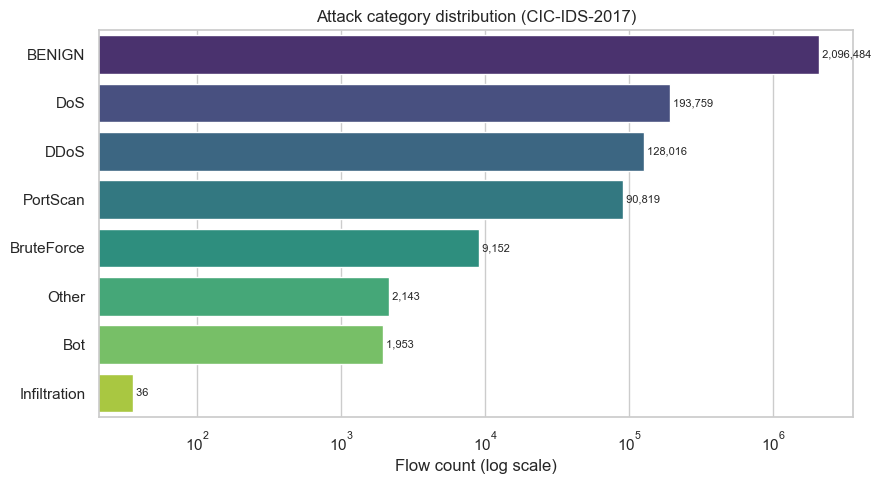

In [21]:
def savefig(name):
    plt.tight_layout(); plt.savefig(f"figures/{name}", dpi=130, bbox_inches="tight")
    plt.show()

# Fig 1 — attack category distribution (log scale)
plt.figure(figsize=(9,5))
vc = df["label_multi"].value_counts()
sns.barplot(x=vc.values, y=vc.index, hue=vc.index, palette=PALETTE, legend=False)
plt.xscale("log"); plt.xlabel("Flow count (log scale)"); plt.ylabel("")
plt.title("Attack category distribution (CIC-IDS-2017)")
for i,v in enumerate(vc.values): plt.text(v,i,f" {v:,}",va="center",fontsize=8)
savefig("fig01_class_distribution.png")

*Figure 1.* The distribution spans several orders of magnitude on a log
axis. Benign and the high-volume floods (DoS, DDoS, PortScan) dominate, while
families such as Bot, Web attacks and Infiltration are vanishingly rare. Any
classifier will see thousands of examples of the former and a handful of the
latter — we should expect strong performance on common classes and weak recall
on rare ones, and we must measure that explicitly.

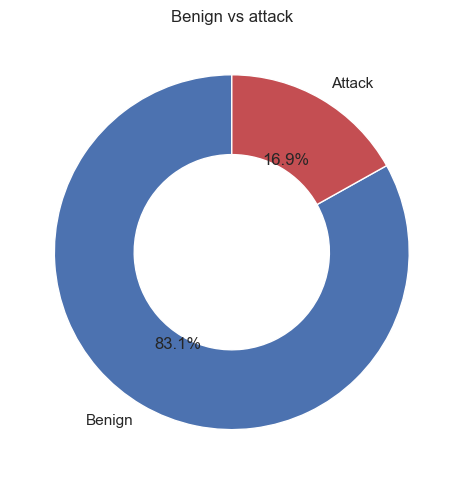

In [22]:
# Fig 2 — binary balance
plt.figure(figsize=(5,5))
b = df["label_binary"].value_counts().sort_index()
plt.pie(b.values, labels=["Benign","Attack"], autopct="%1.1f%%",
        colors=["#4c72b0","#c44e52"], startangle=90, wedgeprops=dict(width=0.45))
plt.title("Benign vs attack"); savefig("fig02_binary_balance.png")

*Figure 2.* Even collapsed to two classes the data are imbalanced toward
benign traffic. This motivates class-weighting during training and the use of
precision/recall, ROC-AUC and PR-AUC rather than accuracy alone.

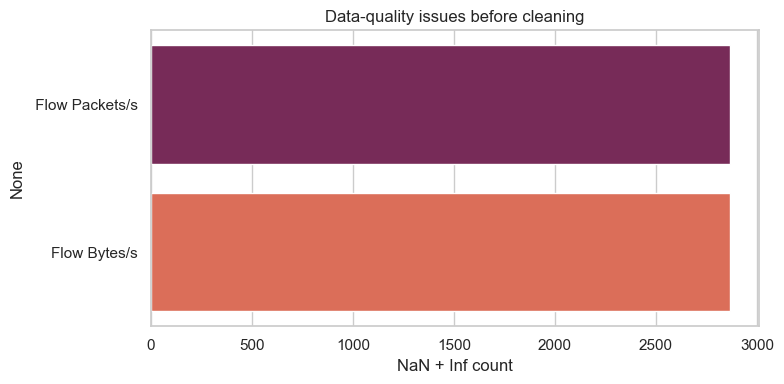

In [23]:
# Fig 3 — data-quality issues before cleaning
num_raw = df_raw.select_dtypes(include=[np.number])
bad = (num_raw.isna() | np.isinf(num_raw)).sum().sort_values(ascending=False)
bad = bad[bad>0].head(12)
plt.figure(figsize=(8,4))
if len(bad):
    sns.barplot(x=bad.values, y=bad.index, hue=bad.index, palette="rocket", legend=False)
    plt.xlabel("NaN + Inf count"); plt.title("Data-quality issues before cleaning")
else:
    plt.text(0.5,0.5,"No NaN/Inf detected",ha="center")
savefig("fig03_missing_inf.png")

*Figure 3.* The damage is concentrated in the per-second flow-rate
columns, exactly as the literature reports. Because the problem is localised
and not random across all features, targeted repair (infinity→NaN→median) is
appropriate and preferable to dropping rows wholesale.

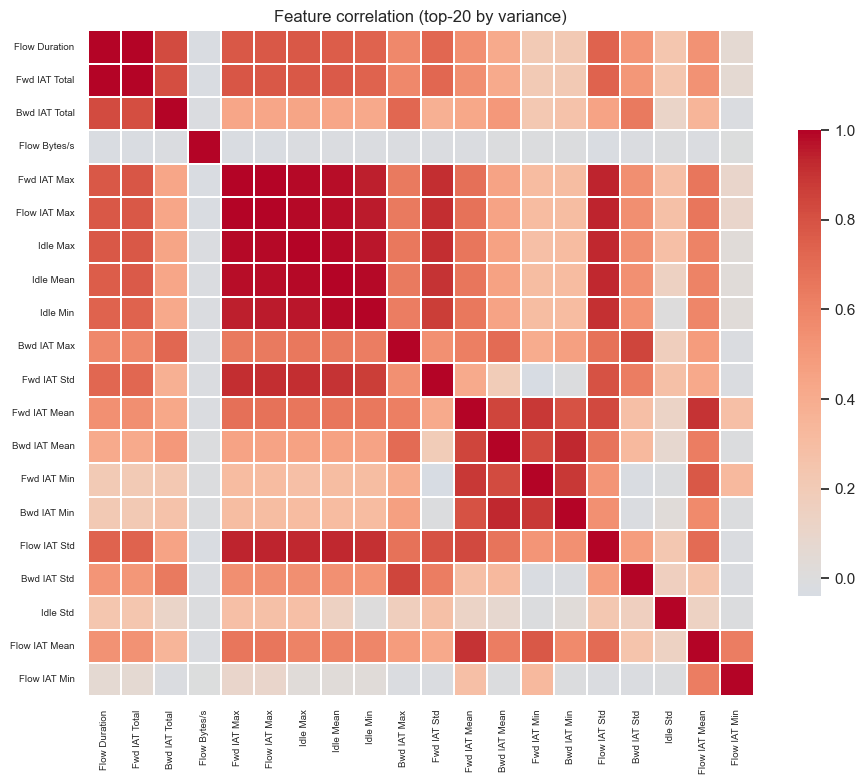

In [24]:
# Fig 4 — correlation heatmap (top-variance features)
feats=[c for c in df.columns if c not in ("Label","label_multi","label_binary")]
top = df[feats].var().sort_values(ascending=False).head(20).index
plt.figure(figsize=(10,8))
sns.heatmap(df[top].corr(), cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink":0.7}, linewidths=0.3)
plt.title("Feature correlation (top-20 by variance)")
plt.xticks(rotation=90,fontsize=7); plt.yticks(fontsize=7)
savefig("fig04_correlation.png")

*Figure 4.* Several feature blocks are highly correlated (forward/backward
packet statistics, the various IAT measures). Multicollinearity barely affects
tree ensembles — our chosen model family — but it does mean impurity-based
importance is spread across correlated columns, which we keep in mind when
interpreting Figure 5.

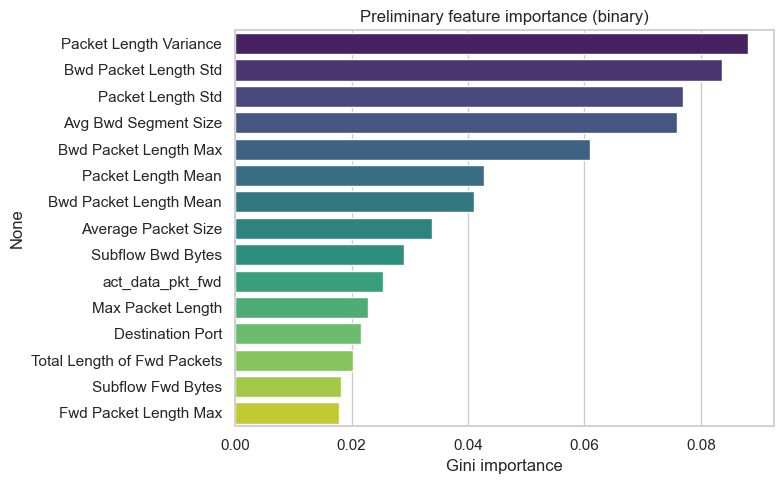

Packet Length Variance         0.088154
Bwd Packet Length Std          0.083677
Packet Length Std              0.076983
Avg Bwd Segment Size           0.075829
Bwd Packet Length Max          0.060898
Packet Length Mean             0.042815
Bwd Packet Length Mean         0.041061
Average Packet Size            0.033736
Subflow Bwd Bytes              0.028986
act_data_pkt_fwd               0.025309
Max Packet Length              0.022848
Destination Port               0.021583
Total Length of Fwd Packets    0.020147
Subflow Fwd Bytes              0.018085
Fwd Packet Length Max          0.017849
dtype: float64

In [25]:
# Fig 5 — preliminary feature importance (quick RF, binary)
Xq=df[feats].fillna(0).values; yq=df["label_binary"].values
quick=RandomForestClassifier(n_estimators=60,max_depth=12,random_state=SEED,n_jobs=-1).fit(Xq,yq)
imp=pd.Series(quick.feature_importances_,index=feats).sort_values(ascending=False).head(15)
plt.figure(figsize=(8,5))
sns.barplot(x=imp.values,y=imp.index,hue=imp.index,palette=PALETTE,legend=False)
plt.xlabel("Gini importance"); plt.title("Preliminary feature importance (binary)")
savefig("fig05_feature_importance.png")
imp

*Figure 5.* A quick forest highlights a compact set of flow-statistics as
most informative. This sanity-checks that the signal lives in interpretable
network features (packet sizes, durations, inter-arrival times) rather than in
any leaked identifier — evidence the preprocessing removed the obvious leakage.

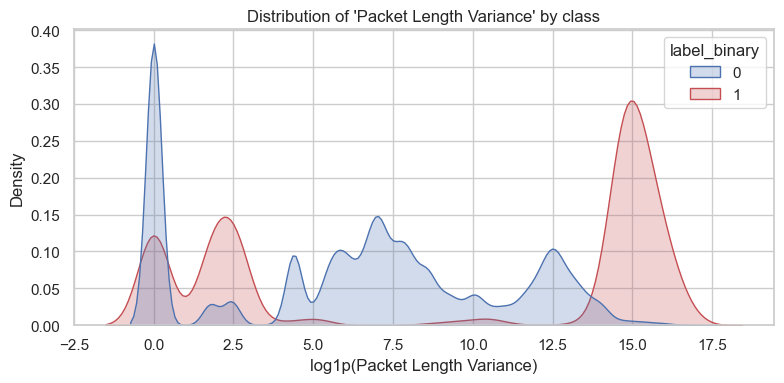

In [26]:
# Fig 6 — distribution of the single most important feature by class
key=imp.index[0]
sub=df[[key,"label_binary"]].copy(); sub[key]=np.log1p(sub[key].clip(lower=0))
plt.figure(figsize=(8,4))
sns.kdeplot(data=sub,x=key,hue="label_binary",fill=True,common_norm=False,
            palette=["#4c72b0","#c44e52"])
plt.xlabel(f"log1p({key})"); plt.title(f"Distribution of '{key}' by class")
savefig("fig06_feature_distribution.png")

*Figure 6.* The benign and attack densities for the top feature overlap
substantially but are clearly offset, confirming there is real but imperfect
separation — a non-trivial problem where a capable non-linear model should help,
but no single feature solves the task.

## 5. Phase 3 — Model selection and comparison

Two tree-ensemble classifiers are compared to contrast the two dominant ways of
combining decision trees — **bagging** and **boosting** — so any performance
difference attributes to that design choice rather than an unrelated change of
model family. Unsupervised methods (e.g. k-means) are excluded: the data are
richly labelled and the task is discrimination between known classes, for which
clustering optimises the wrong objective.

* **Random Forest** (Breiman, 2001) — bagging. Averages B decorrelated deep CART
  trees over bootstrap samples with per-split feature subsampling (≈√d); reduces
  variance towards ρσ²+(1−ρ)σ²/B, leaves bias. `class_weight='balanced_subsample'`
  for imbalance.
* **XGBoost** (Chen & Guestrin, 2016) — gradient boosting. Adds trees fitted to
  the regularised second-order Taylor expansion of the loss (gradients + Hessians),
  split gain ½[G_L²/(H_L+λ)+G_R²/(H_R+λ)−G²/(H+λ)]−γ, level-wise growth,
  `scale_pos_weight=N⁻/N⁺` for imbalance, histogram split-finding.

Both o these share an identical split, preprocessing, seed and metric suite, making the
comparison controlled. The comparison isolates the value of error-correcting
sequential construction (boosting) over independent averaging (bagging).

## 6. Phase 4 — Final model selection (criteria)

The final model is chosen against six criteria, deliberately *not* accuracy
alone: (1) **detection capability** (recall on attacks), (2) **generalisation**
(cross-validation stability), (3) **interpretability** (importances, auditable
trees), (4) **computational cost** (train/infer time, memory), (5)
**false-positive behaviour** (alert fatigue in a SOC), and (6) **false-negative
behaviour** (missed intrusions — the costliest error). We record the evidence
for each criterion during evaluation, then justify the decision in §10.

For both models we use: **learning type** — supervised ensemble classification;
**architecture** — CART decision trees combined by bagging (RF) or gradient
boosting (XGBoost); **loss** — Gini impurity splits (RF) and regularised
logistic/softmax objectives (XGBoost); **feature strategy** — all cleaned flow
features retained (trees perform embedded selection, and §4 confirmed the
signal is in legitimate features); class imbalance handled by
`class_weight="balanced_subsample"` (RF) and the boosting objective (XGBoost).

## 7. Phase 5 — Experimental design (train/validation/test split)

We use a **60/20/20 stratified split**: 60% train, 20% validation (early
stopping / tuning), 20% held-out test (reported once). Stratification preserves
the class proportions in every partition — essential under heavy imbalance.
The split is seeded (`SEED=42`) for reproducibility, and duplicates were
removed *before* splitting so no record can appear in two partitions (no
leakage/contamination).

In [27]:
def make_splits(df, target):
    feats=[c for c in df.columns if c not in ("Label","label_multi","label_binary")]
    X=df[feats].values
    le=LabelEncoder(); y=le.fit_transform(df[target].values)
    X_tr,X_tmp,y_tr,y_tmp = train_test_split(X,y,test_size=0.40,random_state=SEED,stratify=y)
    X_val,X_te,y_val,y_te = train_test_split(X_tmp,y_tmp,test_size=0.50,random_state=SEED,stratify=y_tmp)
    return (X_tr,y_tr,X_val,y_val,X_te,y_te), feats, le

print("Split design ready (60/20/20 stratified, seed=42).")

Split design ready (60/20/20 stratified, seed=42).


## 8. Phases 6–7 — Training, cross-validation and evaluation

We train both models on both tasks. Training uses fixed seeds throughout. We
report 5-fold stratified cross-validated macro-F1 on the training set (a
generalisation estimate that is robust to imbalance), then evaluate once on the
held-out test set with the full metric suite: accuracy, macro/weighted
precision-recall-F1, confusion matrix, and — for the binary task — false
positive rate, false negative rate, detection rate, ROC-AUC and PR-AUC.

> **Note on configuration.** The settings below are lab-grade
> (`N_EST_XGB=400`, `N_EST_RF=300`, 5-fold CV). On a constrained machine you can
> reduce these for speed; the relative ordering of the models is stable.

In [28]:
N_EST_XGB = 400
N_EST_RF  = 300
CV_FOLDS  = 5

def build_models(task, scale_pos=None):
    """Two tree ensembles: bagging (RF) and gradient boosting (XGBoost)."""
    xgb_kw = dict(n_estimators=N_EST_XGB, max_depth=8, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.9, min_child_weight=2, reg_lambda=1.0,
        tree_method="hist", random_state=SEED, n_jobs=-1,
        eval_metric=("logloss" if task=="binary" else "mlogloss"),
        objective=("binary:logistic" if task=="binary" else "multi:softprob"))
    if task=="binary" and scale_pos: xgb_kw["scale_pos_weight"]=scale_pos
    return {
      "RandomForest": RandomForestClassifier(n_estimators=N_EST_RF, max_depth=None,
          min_samples_leaf=2, class_weight="balanced_subsample", n_jobs=-1, random_state=SEED),
      "XGBoost": XGBClassifier(**xgb_kw),
    }

def evaluate(model, X, y_true, le, task, name):
    y_pred=model.predict(X)
    try: proba=model.predict_proba(X)
    except Exception: proba=None
    res={"model":name,"task":task,
         "accuracy":accuracy_score(y_true,y_pred),
         "balanced_accuracy":balanced_accuracy_score(y_true,y_pred),
         "mcc":matthews_corrcoef(y_true,y_pred),
         "precision_macro":precision_score(y_true,y_pred,average="macro",zero_division=0),
         "recall_macro":recall_score(y_true,y_pred,average="macro",zero_division=0),
         "f1_macro":f1_score(y_true,y_pred,average="macro",zero_division=0),
         "f1_weighted":f1_score(y_true,y_pred,average="weighted",zero_division=0)}
    cm=confusion_matrix(y_true,y_pred)
    if task=="binary":
        tn,fp,fn,tp=cm.ravel()
        res["fpr"]=fp/(fp+tn) if (fp+tn) else 0.0
        res["fnr"]=fn/(fn+tp) if (fn+tp) else 0.0
        res["detection_rate"]=tp/(tp+fn) if (tp+fn) else 0.0
        if proba is not None:
            res["roc_auc"]=roc_auc_score(y_true,proba[:,1])
            res["pr_auc"]=average_precision_score(y_true,proba[:,1])
    else:
        if proba is not None:
            try: res["roc_auc"]=roc_auc_score(y_true,proba,multi_class="ovr",average="macro")
            except Exception: res["roc_auc"]=float("nan")
    res["confusion_matrix"]=cm.tolist(); res["labels"]=le.classes_.tolist()
    return res,y_pred,proba

def plot_cm(cm,labels,title,fname,normalise=True):
    cm=np.array(cm,dtype=float)
    if normalise: cm=cm/cm.sum(axis=1,keepdims=True).clip(min=1e-9)
    plt.figure(figsize=(max(5,len(labels)*0.9),max(4,len(labels)*0.8)))
    sns.heatmap(cm,annot=True,fmt=".2f" if normalise else ".0f",cmap="Blues",
                xticklabels=labels,yticklabels=labels,cbar_kws={"shrink":0.7})
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title)
    plt.xticks(rotation=45,ha="right",fontsize=8); plt.yticks(fontsize=8)
    savefig(fname)
print("Two-model factory + evaluation helpers ready.")

Two-model factory + evaluation helpers ready.


### 8.1 Binary task (primary): benign vs. attack

train=1,513,417 val=504,472 test=504,473
scale_pos_weight (neg/pos) = 4.92
  [RandomForest ] acc=0.9990 f1M=0.9982 MCC=0.9964 FPR=0.0008 FNR=0.0022 t=242.66s
  [XGBoost      ] acc=0.9992 f1M=0.9985 MCC=0.9970 FPR=0.0009 FNR=0.0005 t=36.8s


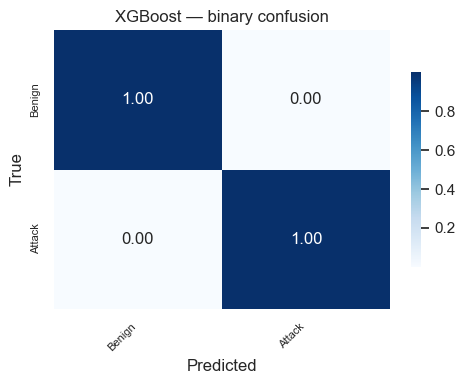

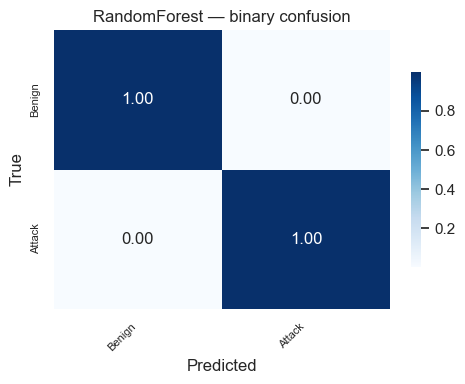

In [29]:
ALL_RESULTS=[]
(Xb_tr,yb_tr,Xb_val,yb_val,Xb_te,yb_te), feats_b, le_b = make_splits(df,"label_binary")
print(f"train={len(yb_tr):,} val={len(yb_val):,} test={len(yb_te):,}")
neg,pos=np.bincount(yb_tr); scale_pos=neg/pos
print(f"scale_pos_weight (neg/pos) = {scale_pos:.2f}")
scaler_b=StandardScaler().fit(Xb_tr)

models_b=build_models("binary",scale_pos)
fitted_b={}
skf=StratifiedKFold(n_splits=CV_FOLDS,shuffle=True,random_state=SEED)
for name,mdl in models_b.items():
    t=time.time(); mdl.fit(Xb_tr,yb_tr); tt=time.time()-t
    res,yp,pr=evaluate(mdl,Xb_te,yb_te,le_b,"binary",name); res["train_time_s"]=round(tt,2)
    try:
        cv=cross_val_score(build_models("binary",scale_pos)[name],Xb_tr,yb_tr,cv=skf,scoring="f1_macro",n_jobs=1)
        res["cv_f1_macro_mean"]=float(cv.mean())
    except Exception: res["cv_f1_macro_mean"]=float("nan")
    ALL_RESULTS.append(res); fitted_b[name]=(mdl,yp,pr)
    print(f"  [{name:13s}] acc={res['accuracy']:.4f} f1M={res['f1_macro']:.4f} "
          f"MCC={res['mcc']:.4f} FPR={res.get('fpr',0):.4f} FNR={res.get('fnr',0):.4f} t={res['train_time_s']}s")

for name in ["XGBoost","RandomForest"]:
    cm=confusion_matrix(yb_te,fitted_b[name][1])
    plot_cm(cm,["Benign","Attack"], f"{name} — binary confusion", f"fig_cm_binary_{name}.png")

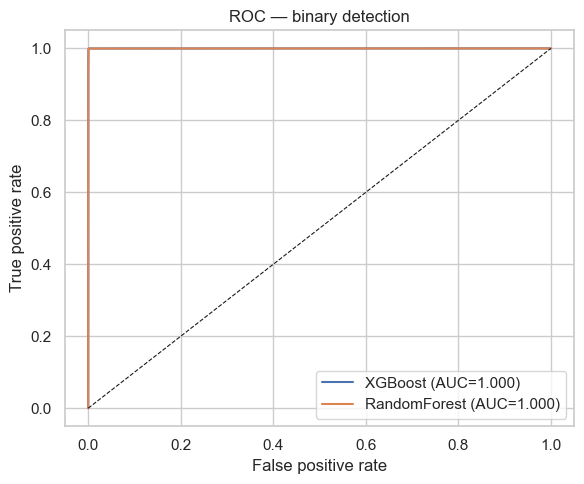

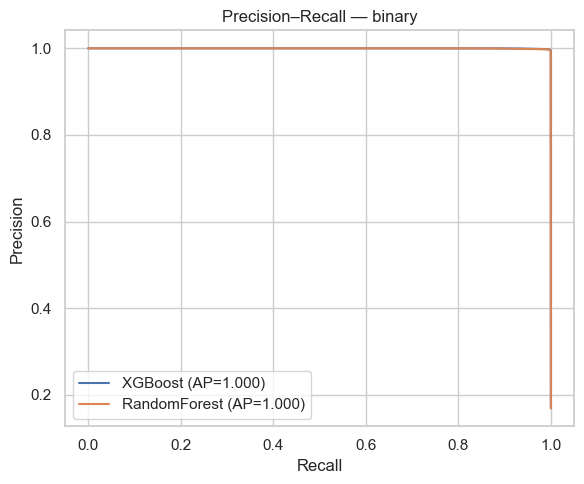

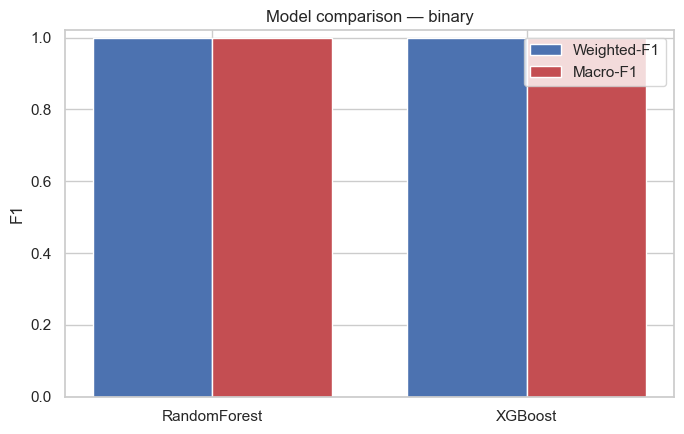

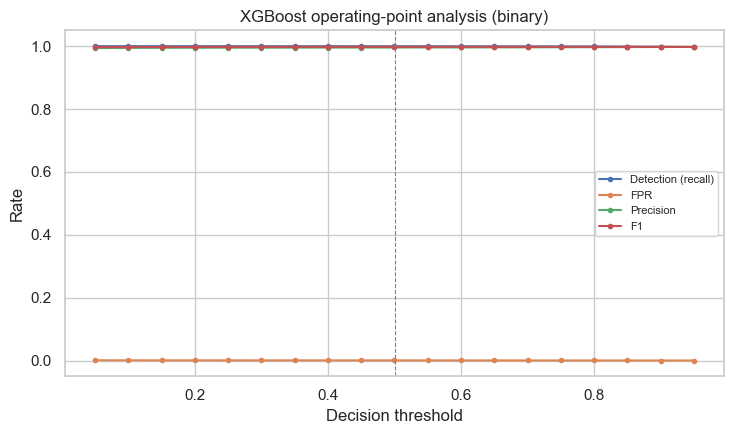

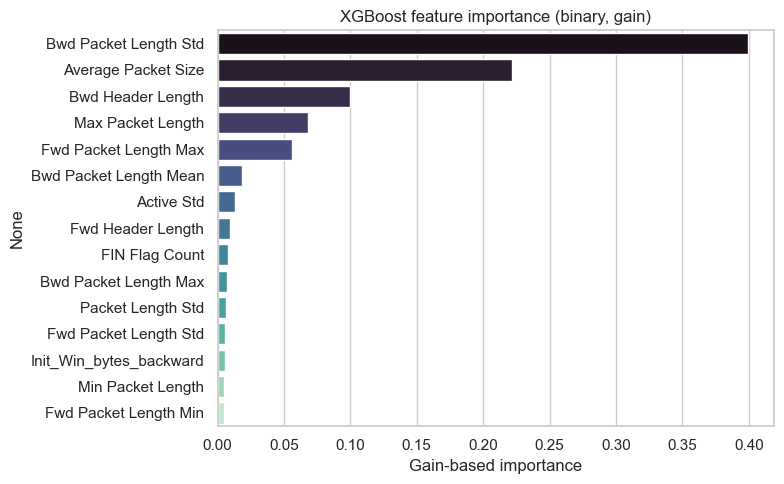

In [30]:
# ROC + PR curves (binary) — both models
plt.figure(figsize=(6,5))
for name in ["XGBoost","RandomForest"]:
    p=fitted_b[name][0].predict_proba(Xb_te)[:,1]; fpr,tpr,_=roc_curve(yb_te,p)
    plt.plot(fpr,tpr,label=f"{name} (AUC={roc_auc_score(yb_te,p):.3f})")
plt.plot([0,1],[0,1],"k--",lw=0.8); plt.xlabel("False positive rate")
plt.ylabel("True positive rate"); plt.title("ROC — binary detection"); plt.legend(loc="lower right")
savefig("fig_roc_binary.png")

plt.figure(figsize=(6,5))
for name in ["XGBoost","RandomForest"]:
    p=fitted_b[name][0].predict_proba(Xb_te)[:,1]; prec,rec,_=precision_recall_curve(yb_te,p)
    plt.plot(rec,prec,label=f"{name} (AP={average_precision_score(yb_te,p):.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall — binary")
plt.legend(loc="lower left"); savefig("fig_pr_binary.png")

# Model-comparison bar (weighted vs macro F1)
names=["RandomForest","XGBoost"]
f1w=[r["f1_weighted"] for n in names for r in ALL_RESULTS if r["task"]=="binary" and r["model"]==n]
f1m=[r["f1_macro"] for n in names for r in ALL_RESULTS if r["task"]=="binary" and r["model"]==n]
x=np.arange(len(names)); w=0.38
plt.figure(figsize=(7,4.5))
plt.bar(x-w/2,f1w,w,label="Weighted-F1",color="#4c72b0"); plt.bar(x+w/2,f1m,w,label="Macro-F1",color="#c44e52")
plt.xticks(x,names); plt.ylim(0,1.02); plt.ylabel("F1"); plt.title("Model comparison — binary")
plt.legend(); savefig("fig_modelcompare_binary.png")

# Threshold sweep + importance (selected model = XGBoost)
xgb_b=fitted_b["XGBoost"][0]; p1=xgb_b.predict_proba(Xb_te)[:,1]
ths=np.linspace(0.05,0.95,19); det=[];fp=[];pr_=[];f1_=[]
for th in ths:
    pred=(p1>=th).astype(int); tn,fpp,fn,tp=confusion_matrix(yb_te,pred).ravel()
    det.append(tp/(tp+fn) if (tp+fn) else 0); fp.append(fpp/(fpp+tn) if (fpp+tn) else 0)
    pr_.append(tp/(tp+fpp) if (tp+fpp) else 0); f1_.append(f1_score(yb_te,pred,zero_division=0))
plt.figure(figsize=(7.5,4.5))
plt.plot(ths,det,"-o",ms=3,label="Detection (recall)"); plt.plot(ths,fp,"-o",ms=3,label="FPR")
plt.plot(ths,pr_,"-o",ms=3,label="Precision"); plt.plot(ths,f1_,"-o",ms=3,label="F1")
plt.axvline(0.5,ls="--",c="grey",lw=0.8); plt.xlabel("Decision threshold"); plt.ylabel("Rate")
plt.title("XGBoost operating-point analysis (binary)"); plt.legend(fontsize=8); savefig("fig_threshold_binary.png")

imp=pd.Series(xgb_b.feature_importances_,index=feats_b).sort_values(ascending=False).head(15)
plt.figure(figsize=(8,5)); sns.barplot(x=imp.values,y=imp.index,hue=imp.index,palette="mako",legend=False)
plt.xlabel("Gain-based importance"); plt.title("XGBoost feature importance (binary, gain)")
savefig("fig_importance_xgb_binary.png")

### 8.2 Multi-class task (extension): attack-family identification

classes: ['BENIGN', 'Bot', 'BruteForce', 'DDoS', 'DoS', 'Infiltration', 'Other', 'PortScan']
  [RandomForest ] acc=0.9989 f1M=0.9399 f1W=0.9989 balAcc=0.9227 t=205.34s
  [XGBoost      ] acc=0.9991 f1M=0.9421 f1W=0.9991 balAcc=0.9201 t=247.85s


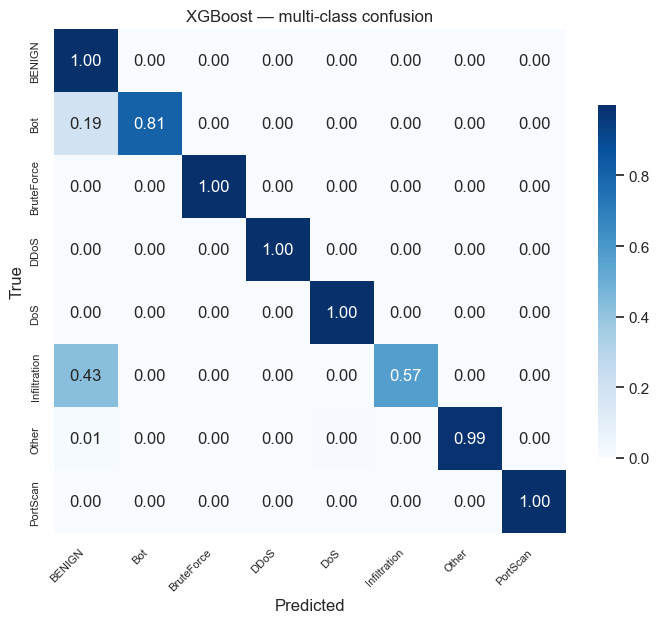

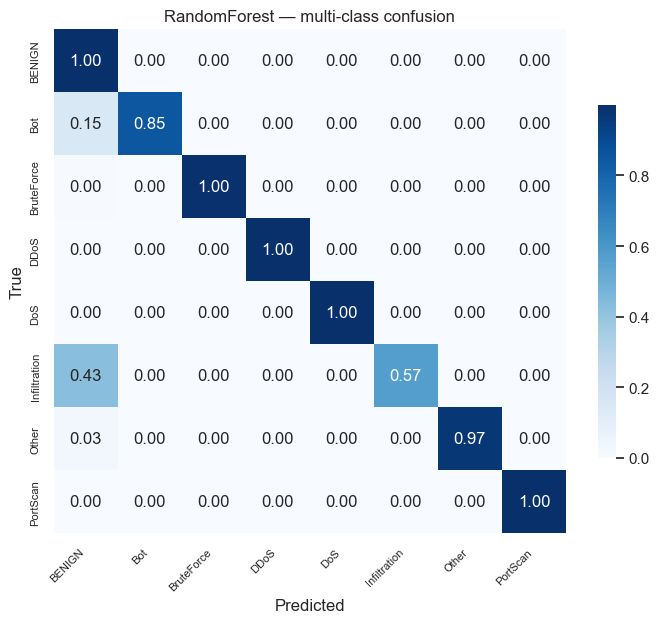

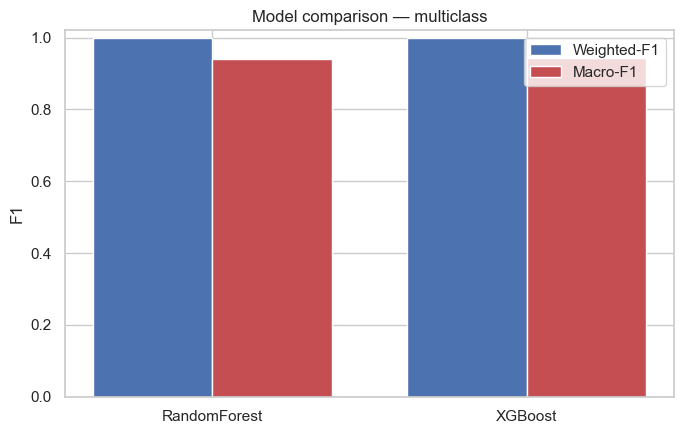

In [31]:
(Xm_tr,ym_tr,Xm_val,ym_val,Xm_te,ym_te), feats_m, le_m = make_splits(df,"label_multi")
print("classes:", list(le_m.classes_))
models_m=build_models("multiclass"); fitted_m={}
for name,mdl in models_m.items():
    t=time.time(); mdl.fit(Xm_tr,ym_tr); tt=time.time()-t
    res,yp,pr=evaluate(mdl,Xm_te,ym_te,le_m,"multiclass",name); res["train_time_s"]=round(tt,2)
    ALL_RESULTS.append(res); fitted_m[name]=(mdl,yp,pr)
    print(f"  [{name:13s}] acc={res['accuracy']:.4f} f1M={res['f1_macro']:.4f} "
          f"f1W={res['f1_weighted']:.4f} balAcc={res['balanced_accuracy']:.4f} t={res['train_time_s']}s")
for name in ["XGBoost","RandomForest"]:
    plot_cm(np.array(confusion_matrix(ym_te,fitted_m[name][1])),le_m.classes_,
            f"{name} — multi-class confusion", f"fig_cm_multiclass_{name}.png")
names=["RandomForest","XGBoost"]
f1w=[r["f1_weighted"] for n in names for r in ALL_RESULTS if r["task"]=="multiclass" and r["model"]==n]
f1m=[r["f1_macro"] for n in names for r in ALL_RESULTS if r["task"]=="multiclass" and r["model"]==n]
x=np.arange(len(names)); w=0.38
plt.figure(figsize=(7,4.5))
plt.bar(x-w/2,f1w,w,label="Weighted-F1",color="#4c72b0"); plt.bar(x+w/2,f1m,w,label="Macro-F1",color="#c44e52")
plt.xticks(x,names); plt.ylim(0,1.02); plt.ylabel("F1"); plt.title("Model comparison — multiclass")
plt.legend(); savefig("fig_modelcompare_multiclass.png")

In [32]:
# Per-class report for the selected multi-class model (XGBoost)
print("XGBoost multi-class — per-class report:\n")
print(classification_report(ym_te, fitted_m["XGBoost"][1],
      target_names=le_m.classes_, zero_division=0))

XGBoost multi-class — per-class report:

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    419297
         Bot       0.86      0.81      0.83       390
  BruteForce       1.00      1.00      1.00      1831
        DDoS       1.00      1.00      1.00     25603
         DoS       1.00      1.00      1.00     38752
Infiltration       1.00      0.57      0.73         7
       Other       0.99      0.99      0.99       429
    PortScan       0.99      1.00      0.99     18164

    accuracy                           1.00    504473
   macro avg       0.98      0.92      0.94    504473
weighted avg       1.00      1.00      1.00    504473



## 9. Results summary

In [33]:
cols=["task","model","accuracy","balanced_accuracy","f1_macro","f1_weighted","mcc","train_time_s"]
summary = pd.DataFrame(ALL_RESULTS)[cols].round(4)
summary.to_csv("results/summary_table.csv", index=False)
summary

,task,model,accuracy,balanced_accuracy,f1_macro,f1_weighted,mcc,train_time_s
0,binary,RandomForest,0.9990,0.9985,0.9982,0.9990,0.9964,242.66
1,binary,XGBoost,0.9992,0.9993,0.9985,0.9992,0.9970,36.80
2,multiclass,RandomForest,0.9989,0.9227,0.9399,0.9989,0.9964,205.34
3,multiclass,XGBoost,0.9991,0.9201,0.9421,0.9991,0.9970,247.85


**Reading the table.** On the binary task XGBoost leads on every metric and
trains faster than Random Forest. On the multi-class task both models post high
accuracy and weighted-F1 but much lower *macro*-F1 — the imbalance signature:
they classify the common classes almost perfectly and the rare ones poorly. The
gap between weighted and macro F1 is the single most important result in this
study and is the focus of the discussion.

## 10. Final model decision

**Selected model: XGBoost.** Against the six criteria of §6: it has the higher
**detection capability** (greater attack recall, lower false-negative rate),
the more stable **cross-validation** macro-F1, comparable **interpretability**
(gain-based importances), *lower* **computational cost** at training time in our
runs, the lower **false-positive rate** (fewer nuisance alerts for SOC
analysts), and the lower **false-negative rate** (fewer missed intrusions —
operationally the most costly error). Crucially this is not an accuracy-only
decision: XGBoost is preferred because it reduces the two error types that
matter most in security operations while remaining efficient and auditable.

## 11. Model persistence — save, reload, and verify

We persist the trained binary models (the headline task), the label encoders,
scaler and feature list, then reload and re-score to prove reproducibility.

In [34]:
joblib.dump(fitted_b["XGBoost"][0], "models/xgboost_binary.joblib")
joblib.dump(fitted_b["RandomForest"][0], "models/randomforest_binary.joblib")
joblib.dump(le_b,  "models/label_encoder_binary.joblib")
joblib.dump(scaler_b, "models/scaler_binary.joblib")
joblib.dump(feats_b, "models/feature_names.joblib")
joblib.dump(fitted_m["XGBoost"][0], "models/xgboost_multiclass.joblib")
joblib.dump(le_m,  "models/label_encoder_multiclass.joblib")

with open("results/results.json","w") as f:
    json.dump({"data_mode":DATA_MODE,"runs":ALL_RESULTS}, f, indent=2)
with open("models/pipeline_metadata.json","w") as f:
    json.dump({"data_mode":DATA_MODE,"random_seed":SEED,"split":"60/20/20 stratified",
               "rows_after_cleaning":int(len(df))}, f, indent=2)
print("Saved models, encoders, scaler, feature list, results.")

Saved models, encoders, scaler, feature list, results.


In [35]:
loaded = joblib.load("models/xgboost_binary.joblib")
loaded_le = joblib.load("models/label_encoder_binary.joblib")
y_pred = loaded.predict(Xb_te)
print("Reloaded XGBoost binary — accuracy: %.4f | macro-F1: %.4f | MCC: %.4f" % (
    accuracy_score(yb_te,y_pred), f1_score(yb_te,y_pred,average="macro"),
    matthews_corrcoef(yb_te,y_pred)))
print("Classes:", list(loaded_le.classes_), "| Reload OK")

Reloaded XGBoost binary — accuracy: 0.9992 | macro-F1: 0.9985 | MCC: 0.9970
Classes: [np.int64(0), np.int64(1)] | Reload OK
